In [ ]:
import os
import cv2
import h5py
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from tensorflow.keras.applications.resnet50 import ResNet50, preprocess_input
from tensorflow.keras.layers import LSTM, Dense, TimeDistributed, Input, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
import tensorflow as tf
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.utils import plot_model

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Loading Dataset

In [ ]:
# Reading the .mat file containing the dataset's description and evaluation metrics
mat_path = '/content/drive/MyDrive/TVSum Dataset/ydata-tvsum50.mat'

with h5py.File(mat_path, 'r') as f:
    print(list(f.keys()))

['#refs#', 'tvsum50']


In [ ]:
# Exploring the attributes in the tvsum file
with h5py.File(mat_path, 'r') as f:
    tvsum = f['tvsum50']
    print(list(tvsum.keys()))

['category', 'gt_score', 'length', 'nframes', 'title', 'user_anno', 'video']


In [ ]:
# Exploring how the gt score is divided
with h5py.File(mat_path, 'r') as f:
    tvsum = f['tvsum50']
    print(tvsum['gt_score'].shape)

(50, 1)


In [ ]:
train_frames_dir = '/content/drive/MyDrive/TVSum Dataset/frames/train'
test_frames_dir = '/content/drive/MyDrive/TVSum Dataset/frames/test'
test_video_name = 'uGu_10sucQo'

In [ ]:
# Loading gt_scores as the Y data
with h5py.File(mat_path, 'r') as f:
    tvsum = f['tvsum50']
    gt_scores = []
    for i in range(tvsum['gt_score'].shape[0]): # Looping through each row (video)
        ref = tvsum['gt_score'][i][0] # Video's reference
        shot_scores = np.array(f[ref]).flatten() # Locating the shot scores of each video and storing it as a 1D array
        gt_scores.append(shot_scores)
    # Loading video titles
    video_titles = []
    for i in range(tvsum['video'].shape[0]): # Looping through video titles
        ref = tvsum['video'][i][0]
        title_bytes = f[ref][()] # Numpy or ASCII
        if isinstance(title_bytes, np.ndarray):  # Converting title to an array if it's in ASCII
            title_str = ''.join([chr(c) for c in title_bytes.flatten()]) # Converts title letter by letter
        else:
            title_str = title_bytes.decode() # Convert from bytes to python string
        video_titles.append(title_str)

print("Number of videos in the gt_score: ", len(gt_scores))
print("Number of videos: ",len(video_titles))
print("First video shot shape: ", gt_scores[0].shape)

Number of videos in the gt_score:  50
Number of videos:  50
First video shot shape:  (10597,)


In [ ]:
# Finding the test video's test index
video_idx = video_titles.index(test_video_name)
test_shot_scores = gt_scores[video_titles.index(test_video_name)]
print(f"Test video index: {video_idx}")
print(f"Test video shot-level scores shape: {test_shot_scores.shape}")

Test video index: 36
Test video shot-level scores shape: (4009,)


In [ ]:
# Turning the shots length into frames length
def shots_to_frames(gt_scores, fps=1, shot_length_sec=2):
    frames_per_shot = shot_length_sec * fps # Extending the gt scores to match the number of video frames
    frame_scores = []
    for score in gt_scores:
        frame_scores.extend([score] * frames_per_shot)
    return np.array(frame_scores, dtype=np.float32)

# Applying the function on all training data
all_frame_scores = []
for gt_score in gt_scores:
    frame_scores = shots_to_frames(gt_score)
    all_frame_scores.append(frame_scores)

# Applying the function on the test video frames
test_frame_scores = shots_to_frames(test_shot_scores)

# Preprocessing

In [ ]:
# Train data
X_train = []
Y_train = []
video_folders = [f for f in os.listdir(train_frames_dir) if os.path.isdir(os.path.join(train_frames_dir, f))] # List of all frames folder
video_to_scores = dict(zip(video_titles, all_frame_scores)) # Creating a dictionary of video titles and gt scores

for video_folder in video_folders: # Looping through all video frames folders
    video_path = os.path.join(train_frames_dir, video_folder)
    frame_files = sorted(os.listdir(video_path)) # Sorting them for correct mapping
    frame_scores = video_to_scores[video_folder] # Mapping each score with its correct frame
    n_frames = min(len(frame_files), len(frame_scores))
    for i in range(n_frames): # Adding the frames and scores to arrays
        X_train.append(os.path.join(video_path, frame_files[i]))
        Y_train.append(frame_scores[i])

print("Total frames:", len(X_train))
print("Total labels:", len(Y_train))

Total frames: 12757
Total labels: 12757


In [ ]:
# Test data
X_test = []
Y_test = []
frame_files = sorted(os.listdir(test_frames_dir))  # List of all testing frames
for i in range(30): # Taking only the first 30 seconds of the video
    X_test.append(os.path.join(test_frames_dir, frame_files[i]))
    Y_test.append(test_frame_scores[i])

In [ ]:
# Splitting the dataset into training and validation samples
x_train, x_val, y_train, y_val = train_test_split(X_train, Y_train, test_size=0.1, random_state=42, shuffle=True)

In [ ]:
# Parsing and preprocessing all images
def preprocess_image(path, score):
    img = tf.io.read_file(path) # Reading the image
    img = tf.image.decode_jpeg(img, channels=3) # Decoding it into an RGB img
    img = tf.image.resize(img, [128, 128]) # Resizing to 128x128
    img = preprocess_input(img) # ResNet preprocessing
    return img, score

In [ ]:
# Preprocessing the train, val, and test data
train_preprocessed = tf.data.Dataset.from_tensor_slices((x_train, y_train))
train_preprocessed = train_preprocessed.map(preprocess_image, num_parallel_calls=tf.data.AUTOTUNE)

val_preprocessed = tf.data.Dataset.from_tensor_slices((x_val, y_val))
val_preprocessed = val_preprocessed.map(preprocess_image, num_parallel_calls=tf.data.AUTOTUNE)

test_preprocessed = tf.data.Dataset.from_tensor_slices((X_test, Y_test))
test_preprocessed = test_preprocessed.map(preprocess_image, num_parallel_calls=tf.data.AUTOTUNE)

In [ ]:
# Dividing the data into sequences of length 16 for the LSTM
def sequence(data, seq_len=16):
    data = data.window(seq_len, shift=1, drop_remainder=True)  # Converts individual frames into overlapping sequences with a shift of 1 stride, discarding incomplete sequences
    data = data.flat_map(lambda x, y: tf.data.Dataset.zip((x.batch(seq_len), y.batch(seq_len)))) # Turn the data into a tensor
    data = data.batch(8, drop_remainder=True) # Divides the dataset into batches of 8 sequences
    return data

# Dividing data to sequences
train_seq = sequence(train_preprocessed)
val_seq = sequence(val_preprocessed)
test_seq = sequence(test_preprocessed)

In [ ]:
# Repeating the dataset to avoid stopping after the first epoch
train_seq = train_seq.repeat()
val_seq = val_seq.repeat()

# ResNet + LSTM

In [ ]:
# Loading a pre-traind ResNet50 model
resnet = ResNet50(weights='imagenet', include_top=False, input_shape=(128, 128,3))

resnet.trainable = False # Freezing layers

resnet_input = Input(shape=(16, 128, 128, 3))
x = TimeDistributed(resnet)(resnet_input) # ResNet feature extraction on each frame
x = TimeDistributed(GlobalAveragePooling2D())(x)
x = LSTM(128, return_sequences=True)(x) # LSTM layer
x = Dropout(0.2)(x)
output = TimeDistributed(Dense(1, activation='linear'))(x) # Final Dense layer to produce a final score

In [ ]:
model = Model(resnet_input, output)
model.compile(optimizer='adam', loss='mse')

In [ ]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 16, 128, 128,   │             0 │
│                                 │ 3)                     │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed                │ (None, 16, 4, 4, 2048) │    23,587,712 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_1              │ (None, 16, 2048)       │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 16, 128)        │     1,114,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_2              │ (None, 16, 1)          │           129 │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,702,465 (94.23 MB)

 Trainable params: 1,114,753 (4.25 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

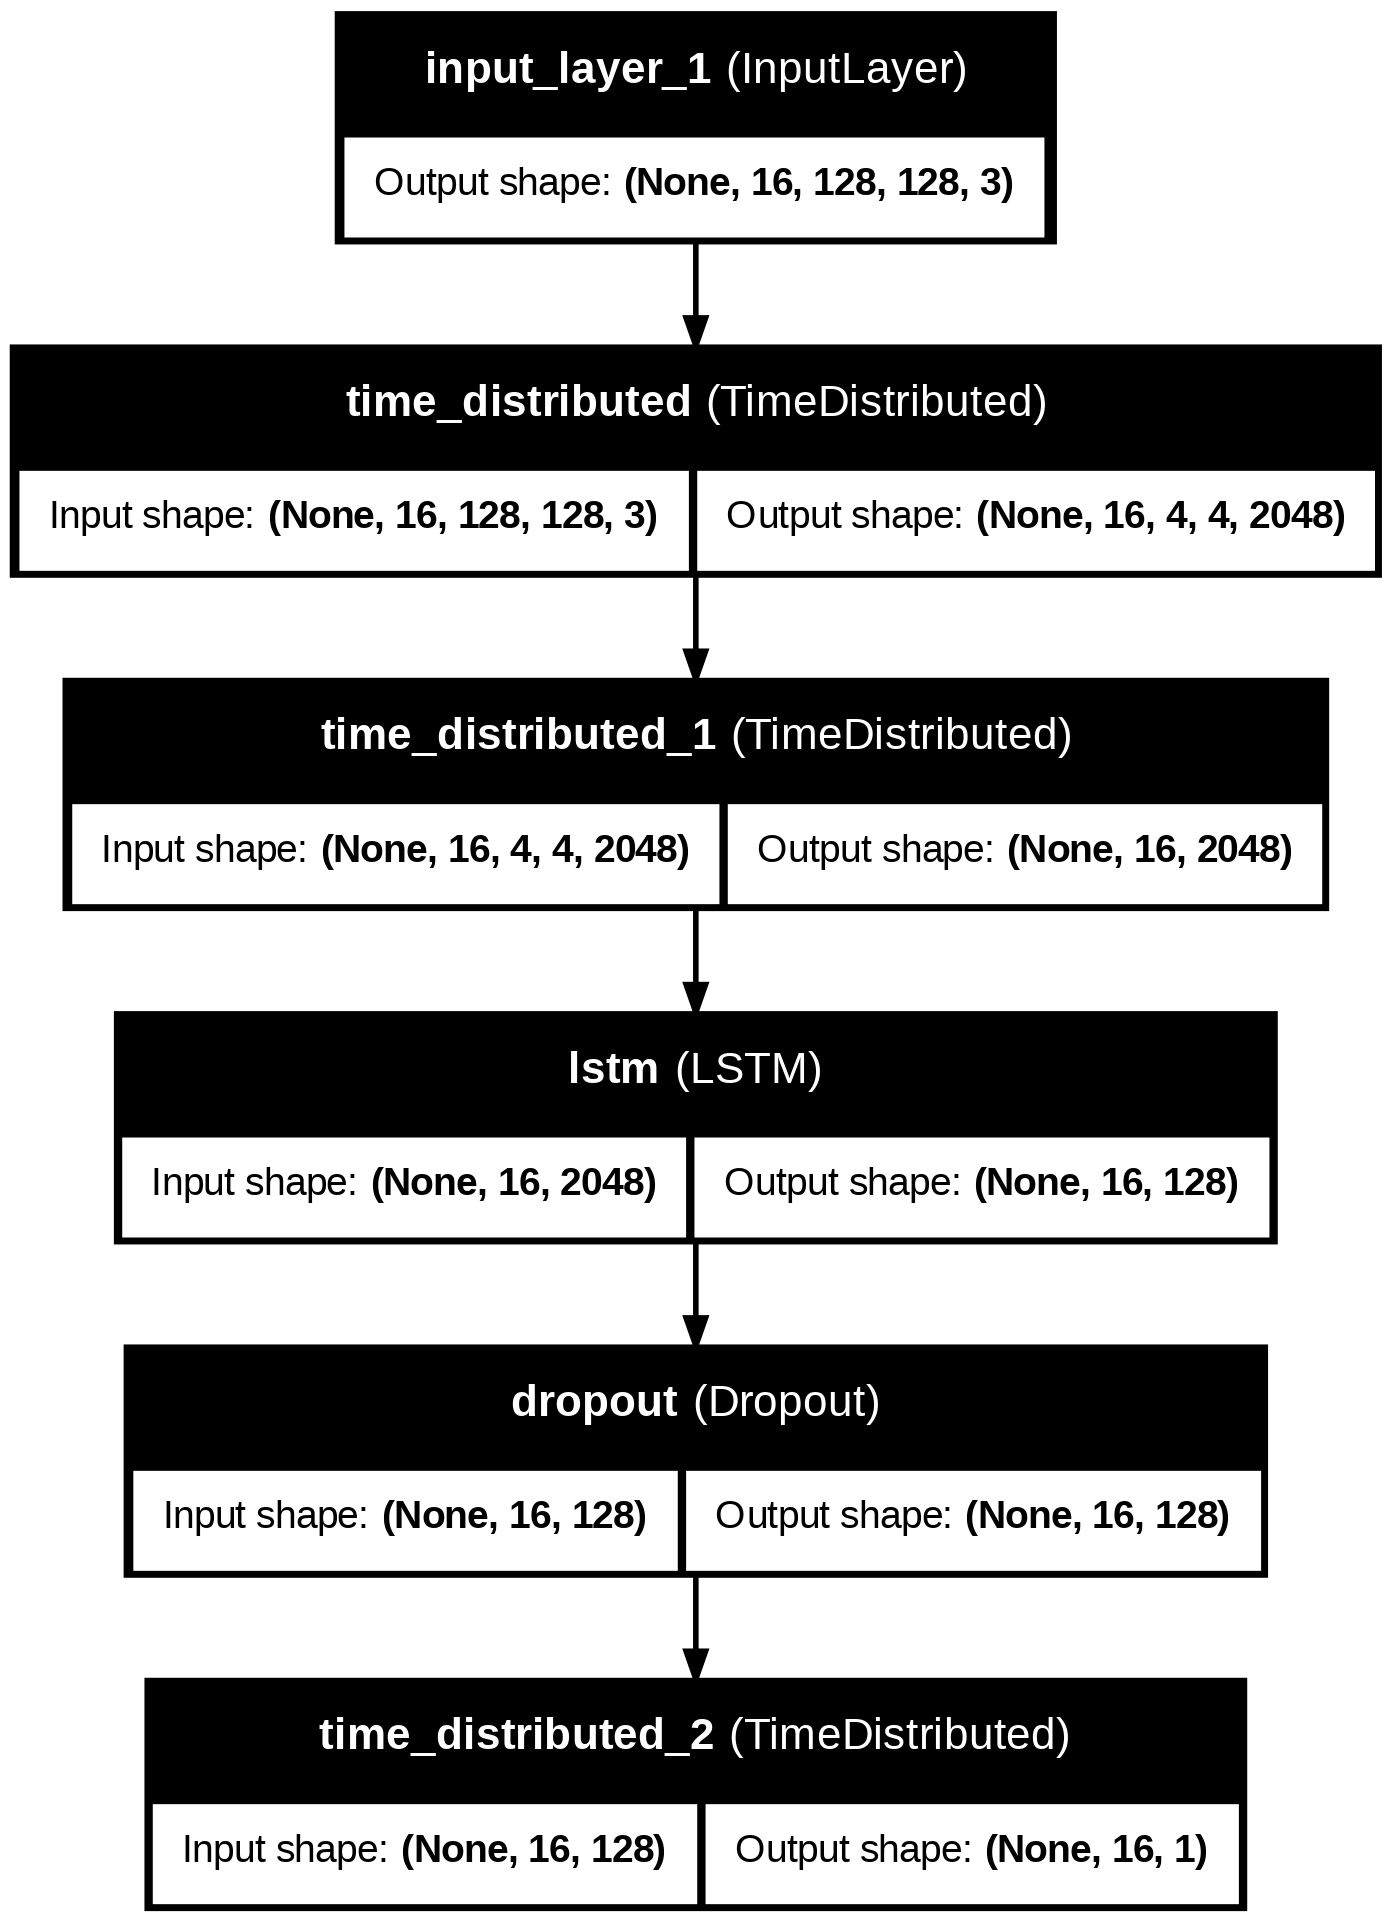

In [ ]:
plot_model(model, show_shapes=True, show_layer_names=True)

In [ ]:
early_stop = EarlyStopping(monitor='val_loss', patience=3) # Stopping when the validation loss stops improving for 3 epochs
epoch_steps = len(x_train) // 16 // 8 # Calculating the number of steps for each epoch based in the sequence length and batch size
val_steps = len(x_val) // 16 // 8

In [ ]:
# Model training
history = model.fit(train_seq, validation_data=val_seq, steps_per_epoch=epoch_steps, validation_steps=val_steps, epochs=20,callbacks=[early_stop])

Epoch 1/20
89/89 ━━━━━━━━━━━━━━━━━━━━ 46s 344ms/step - loss: 1.1663 - val_loss: 0.2102
Epoch 2/20
89/89 ━━━━━━━━━━━━━━━━━━━━ 26s 294ms/step - loss: 0.2601 - val_loss: 0.1951
Epoch 3/20
89/89 ━━━━━━━━━━━━━━━━━━━━ 27s 299ms/step - loss: 0.2609 - val_loss: 0.1942
Epoch 4/20
89/89 ━━━━━━━━━━━━━━━━━━━━ 26s 295ms/step - loss: 0.2611 - val_loss: 0.1896
Epoch 5/20
89/89 ━━━━━━━━━━━━━━━━━━━━ 26s 295ms/step - loss: 0.2276 - val_loss: 0.1859
Epoch 6/20
89/89 ━━━━━━━━━━━━━━━━━━━━ 110s 1s/step - loss: 0.2217 - val_loss: 0.1936
Epoch 7/20
89/89 ━━━━━━━━━━━━━━━━━━━━ 109s 1s/step - loss: 0.1904 - val_loss: 0.1692
Epoch 8/20
89/89 ━━━━━━━━━━━━━━━━━━━━ 108s 1s/step - loss: 0.2104 - val_loss: 0.1823
Epoch 9/20
89/89 ━━━━━━━━━━━━━━━━━━━━ 107s 1s/step - loss: 0.1988 - val_loss: 0.1823
Epoch 10/20
89/89 ━━━━━━━━━━━━━━━━━━━━ 109s 1s/step - loss: 0.1740 - val_loss: 0.1552
Epoch 11/20
89/89 ━━━━━━━━━━━━━━━━━━━━ 110s 1s/step - loss: 0.1925 - val_loss: 0.1559
Epoch 12/20
89/89 ━━━━━━━━━━━━━━━━━━━━ 109s 1s/step -

In [ ]:
# Evalating the model with the test video
model.evaluate(test_seq)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 527ms/step - loss: 0.6478


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:160: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


0.647763729095459

In [ ]:
# Predicting
preds = model.predict(test_seq)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 499ms/step


In [ ]:
preds.shape

(8, 16, 1)

In [ ]:
sequence_pred = preds.squeeze(-1)  # Removing the last dimension (1), new shape=(15,16)

all_predicted_scores = [] # List of lists containing the predicted scores
for _ in range(30):
    all_predicted_scores.append([])

In [ ]:
# Mapping each predicted score from sequences to the actual frames
for sequence_idx, sequence in enumerate(sequence_pred):
    for i, predicted_score in enumerate(sequence):
        frame_idx = sequence_idx + i # Actual frame index
        if frame_idx < 30: # Include only the frames in the first 30 senconds of the video
            all_predicted_scores[frame_idx].append(predicted_score)

In [ ]:
# Taking the average the overlapping predictions
average_frame_scores = []
for score in all_predicted_scores:
  if len(score) == 0:
    average_score = 0
  else:
    average_score = sum(score) / len(score)
  average_frame_scores.append(average_score)

In [ ]:
# Top K predictions
K = 5
min_gap = 2 # Redundancy avoidance

# Sorting the average scores in ascending order
pred_indices = np.argsort(average_frame_scores)[::-1]

Pred_keyframes = []
# Select k frames with highest predicted gt score, ensuring minimum temporal gap
for i in pred_indices:
  # Check if current frame is far enough from all previously picked frames
    if all(abs(i - p) > min_gap for p in Pred_keyframes):
        Pred_keyframes.append(i)
    if len(Pred_keyframes) == K:
        break

# Sorting the keframes based on their indices
Pred_keyframes = sorted(Pred_keyframes)
print("Indices of top-K keyframes:", Pred_keyframes)

Indices of top-K keyframes: [np.int64(2), np.int64(5), np.int64(10), np.int64(13), np.int64(20)]


In [ ]:
# Sorting the actual scores in ascending order and taking the last K elements
actual_indices = np.argsort(Y_test)[::-1]

# Select k frames with highest actual gt score
actual_keyframes = []
for i in actual_indices:
  # Check if current frame is far enough from all previously picked frames
    if all(abs(i - p) > min_gap for p in actual_keyframes):
        actual_keyframes.append(i)
    if len(actual_keyframes) == K: # Stop if we reached the maximum number K
        break

actual_keyframes = sorted(actual_keyframes)
print("Indices of top-K keyframes:", actual_keyframes)

Indices of top-K keyframes: [np.int64(17), np.int64(20), np.int64(23), np.int64(26), np.int64(29)]


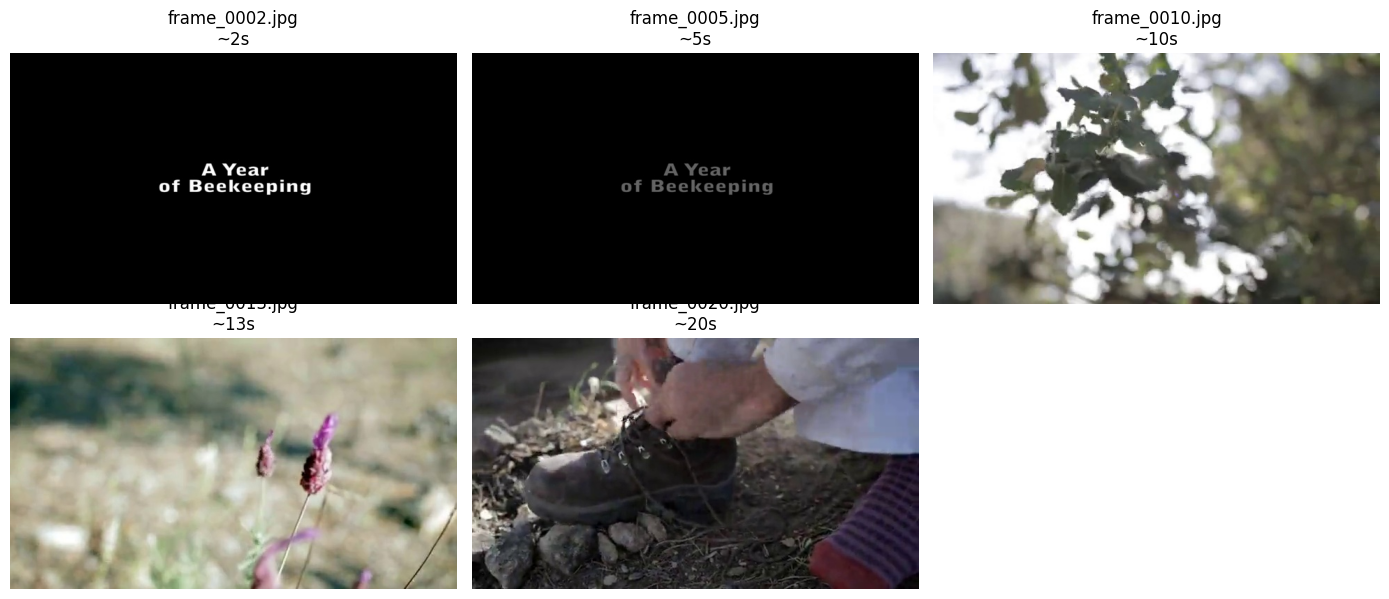

In [ ]:
plt.figure(figsize=(14, 6))

for j, i in enumerate(Pred_keyframes):
    plt.subplot(2, (len(Pred_keyframes)+1)//2, j+1)
    img = cv2.imread(X_test[i])
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    plt.imshow(img)
    plt.title(f"{os.path.basename(X_test[i])}\n~{i}s")
    plt.axis("off")
plt.tight_layout()
plt.show()

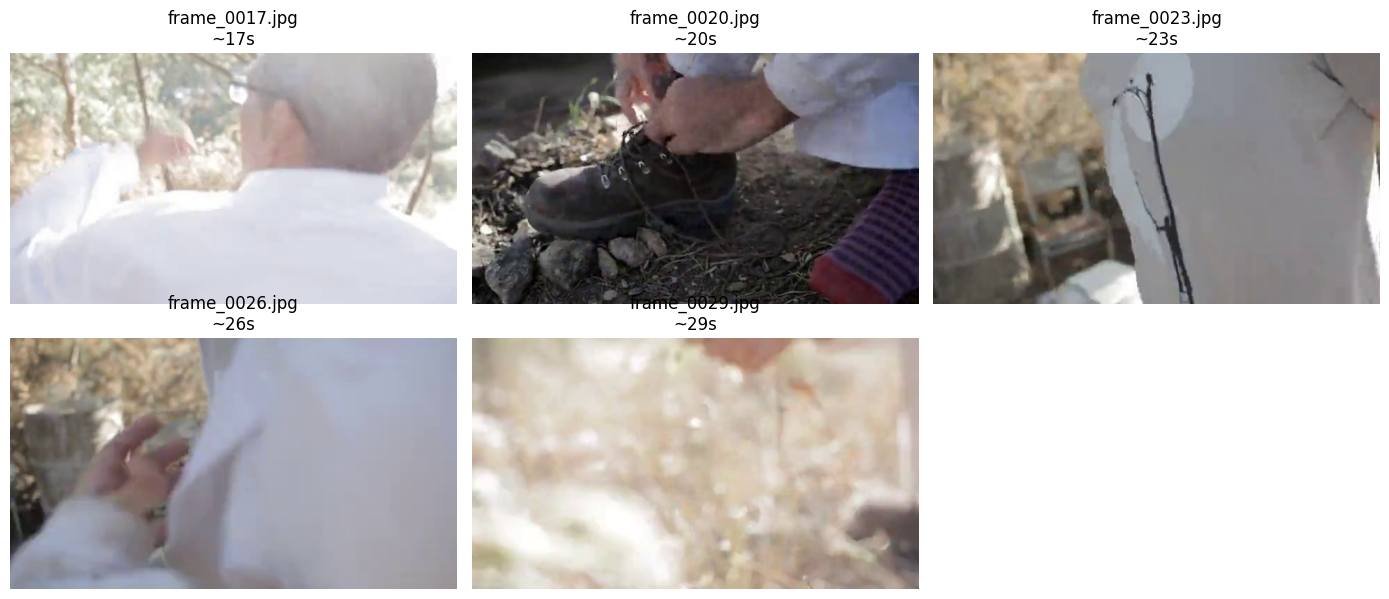

In [ ]:
plt.figure(figsize=(14, 6))

for j, i in enumerate(actual_keyframes):
    plt.subplot(2, (len(actual_keyframes)+1)//2, j+1)
    img = cv2.imread(X_test[i])
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    plt.imshow(img)
    plt.title(f"{os.path.basename(X_test[i])}\n~{i}s")
    plt.axis("off")
plt.tight_layout()
plt.show()

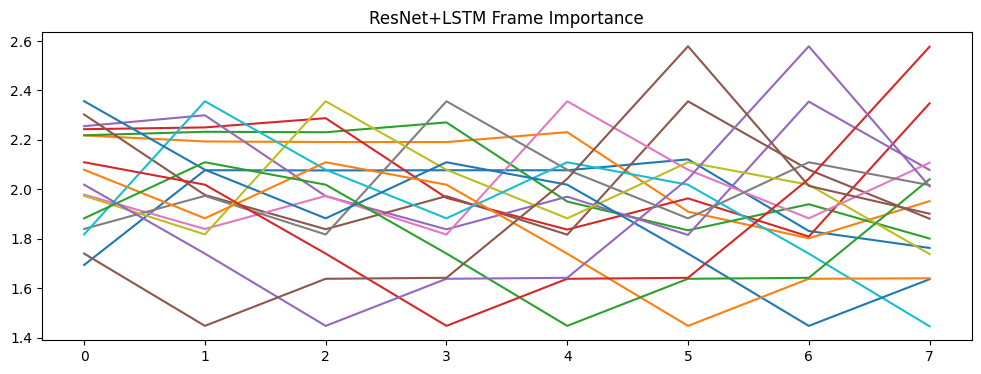

In [ ]:
plt.figure(figsize=(12,4))
plt.plot(sequence_pred)
plt.title("ResNet+LSTM Frame Importance")
plt.show()

In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score

y_true = np.zeros(30, dtype=int)
y_pred = np.zeros(30, dtype=int)

y_true[actual_keyframes] = 1
y_pred[Pred_keyframes] = 1

# Compute metrics
precision = precision_score(y_true, y_pred)
recall = recall_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)

print(f"Precision: {precision}")
print(f"Recall: {recall}")
print(f"F1-score: {f1}")

Precision: 0.2
Recall: 0.2
F1-score: 0.2
